# Dunning-Kruger Classification — Compact Heatmap

A redrawn, condensed version of the classification table. Each cell is now a
flush colour block (no floating pills, no spacing), with no in-cell text and no
numeric trajectories. All meanings live in the **key** only, stated once.

**Categories** (colour only): True DK, Weak DK, Overconfident, Underconfident,
Mixed / non-monotonic.

**Two cell markers:**
- `*` on a blue (Underconfident) cell = *inverse DK* — underconfidence grows with model size.
- A hatched, faded cell = *low-data / provisional* (Gemma MMLUPRO-Base).

**To use:** edit `DATA` (label per cell), then run all cells. The figure renders
inline and is saved as PNG + PDF.

## 1. Imports, palette and configuration

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D

# --- Category palette --------------------------------------------------
# Medium-tone fills so each category reads on colour alone (cells carry no
# text). "edge" is the darker tone reused for borders and markers.
LABEL_STYLES = {
    "DK":  {"fill": "#5CA86A", "edge": "#2F6B36", "name": "True Dunning-Kruger"},
    "WDK": {"fill": "#BEE3B6", "edge": "#5E9C53", "name": "Weak Dunning-Kruger"},
    "OC":  {"fill": "#E08486", "edge": "#B23A3C", "name": "Overconfident"},
    "UC":  {"fill": "#86B7DD", "edge": "#2E6DA4", "name": "Underconfident"},
    "MX":  {"fill": "#EFC15F", "edge": "#C28A1E", "name": "Mixed: shows both under-confidence and over-confidence"},
}

# Faint tint behind each family's label columns (helps grouping at a glance).
FAMILY_TINTS = {"LLaMA": "#EEF3FB", "Qwen": "#EEF5EC", "Gemma": "#FBF1E8"}

# Column-group header colours.
GROUP_COLORS = {"INSTRUCT": "#FFFFFF", "BASE": "#FFFFFF"}

CONFIG = {
    "title": "Dunning-Kruger Classification Across Configurations",
    "subtitle": "Classification based on confidence–accuracy trends across model sizes",
    "column_groups": [
        ("INSTRUCT", ["MMLU", "MMLUPRO"]),
        ("BASE",     ["MMLU", "MMLUPRO"]),
    ],
    "families": ["LLaMA", "Qwen", "Gemma"],
    "metrics":  ["MSP", "Entropy", "Margin", "Verbal", "P(1)", "P(True)"],
}

## 2. Cell data

`DATA[family][metric]` is a list of four entries, one per column in the order
MMLU-Instruct, MMLUPRO-Instruct, MMLU-Base, MMLUPRO-Base.

Each entry is `("LABEL", "")` or `("LABEL", "", flags)`, where `flags` is an
optional dict:
- `{"inverse_dk": True}` on a **UC** cell adds the `*` marker (inverse DK).
- `{"low_data": True}` fades + hatches the cell (provisional).

The second tuple slot used to hold the WDK numeric trajectory; it is kept for
reference but is **no longer drawn**. Allowed labels: `DK`, `WDK`, `OC`, `UC`, `MX`.

In [5]:
DATA = {
    "LLaMA": {
        "MSP":     [("WDK", ""), ("OC", ""), ("UC", ""), ("WDK", "")],
        "Entropy": [("UC", "", {"inverse_dk": True}), ("MX", ""),
                    ("UC", "", {"inverse_dk": True}), ("UC", "")],
        "Margin":  [("MX", ""), ("UC", "", {"inverse_dk": True}),
                    ("UC", "", {"inverse_dk": True}), ("UC", "")],
        "Verbal":  [("MX", ""), ("DK", ""), ("MX", ""), ("MX", "")],
        "P(1)":    [("MX", ""), ("OC", ""), ("MX", ""), ("WDK", "")],
        "P(True)": [("MX", ""), ("MX", ""), ("UC", ""), ("OC", "")],
    },
    "Qwen": {
        "MSP":     [("WDK", ""), ("OC", ""), ("WDK", ""), ("WDK", "")],
        "Entropy": [("WDK", ""), ("OC", ""), ("UC", ""), ("UC", "")],
        "Margin":  [("WDK", ""), ("OC", ""), ("UC", ""), ("UC", "")],
        "Verbal":  [("WDK", ""), ("WDK", ""), ("WDK", ""), ("OC", "")],
        "P(1)":    [("MX", ""), ("OC", ""), ("MX", ""), ("WDK", "")],
        "P(True)": [("UC", "", {"inverse_dk": True}), ("MX", ""),
                    ("MX", ""), ("WDK", "")],
    },
    "Gemma": {
        "MSP":     [("DK", ""), ("OC", ""), ("MX", ""),
                    ("UC", "", {"inverse_dk": True, "low_data": True})],
        "Entropy": [("DK", ""), ("OC", ""), ("UC", ""),
                    ("UC", "", {"inverse_dk": True, "low_data": True})],
        "Margin":  [("DK", ""), ("OC", ""), ("UC", "", {"inverse_dk": True}),
                    ("UC", "", {"inverse_dk": True, "low_data": True})],
        "Verbal":  [("DK", ""), ("OC", ""), ("DK", ""),
                    ("WDK", "", {"low_data": True})],
        "P(1)":    [("DK", ""), ("DK", ""), ("DK", ""),
                    ("MX", "", {"low_data": True})],
        "P(True)": [("WDK", ""), ("OC", ""), ("MX", ""),
                    ("MX", "", {"low_data": True})],
    },
}

## 3. Renderer

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D

def parse_cell(entry):
    """Return (label, inverse_dk, low_data) from a cell tuple."""
    label = entry[0]
    inverse_dk = low_data = False
    if len(entry) >= 3 and isinstance(entry[2], dict):
        inverse_dk = bool(entry[2].get("inverse_dk", False))
        low_data = bool(entry[2].get("low_data", False))
    return label, inverse_dk, low_data


def render_table(config, data,
                 savepath_png="dk_classification_table_compact.png",
                 savepath_pdf="dk_classification_table_compact.pdf"):
    families = config["families"]
    metrics  = config["metrics"]
    groups   = config["column_groups"]
    all_columns = [c for _, cols in groups for c in cols]
    n_cols = len(all_columns)

    # ---- Geometry: compact, uniform short rows ----
    family_col_w, metric_col_w, data_col_w = 1.05, 1.25, 1.55
    row_h = 0.58
    title_h, group_h, colhdr_h = 0.95, 0.42, 0.50
    legend_h, top_pad, bottom_pad = 1.30, 0.15, 0.10

    grid_h  = len(families) * len(metrics) * row_h
    total_w = family_col_w + metric_col_w + n_cols * data_col_w
    total_h = top_pad + title_h + group_h + colhdr_h + grid_h + legend_h + bottom_pad

    scale = 0.74
    fig, ax = plt.subplots(figsize=(total_w * scale, total_h * scale), dpi=150)
    fig.patch.set_facecolor("white")
    ax.set_xlim(0, total_w); ax.set_ylim(0, total_h)
    ax.set_aspect("equal"); ax.axis("off")

    grid_left = family_col_w + metric_col_w
    sep_x = grid_left + len(groups[0][1]) * data_col_w
    DARK, HAIR = "#2B2B2B", "#FFFFFF"

    # ---- Title (clean — no heavy black bar) ----
    title_y = total_h - top_pad - title_h
    ax.text(total_w / 2, title_y + title_h * 0.60, config["title"],
            ha="center", va="center", fontsize=15.5, fontweight="bold", color="#1A1A1A")
    ax.text(total_w / 2, title_y + title_h * 0.18, config["subtitle"],
            ha="center", va="center", fontsize=8.8, color="#6B6B6B")
    ax.plot([0, total_w], [title_y, title_y], color="#334155", linewidth=1.6, zorder=3)

    # ---- Group header (INSTRUCT / BASE) ----
    group_y = title_y - group_h
    cur = grid_left
    for gname, cols in groups:
        span = len(cols) * data_col_w
        ax.add_patch(Rectangle((cur, group_y), span, group_h,
                               facecolor=GROUP_COLORS[gname], edgecolor="none", zorder=2))
        ax.text(cur + span / 2, group_y + group_h / 2, " ".join(gname),
                ha="center", va="center", fontsize=10.5, fontweight="bold",
                color="black", zorder=3)
        cur += span

    # ---- Column sub-labels + Family / Metric headers ----
    colhdr_y = group_y - colhdr_h
    ax.text(family_col_w / 2, colhdr_y + colhdr_h / 2, "Family",
            ha="center", va="center", fontsize=9.5, fontweight="bold", color="#222")
    ax.text(family_col_w + metric_col_w / 2, colhdr_y + colhdr_h / 2, "Metric",
            ha="center", va="center", fontsize=9.5, fontweight="bold", color="#222")
    col_x, cur = [], grid_left
    for label in all_columns:
        col_x.append(cur)
        ax.text(cur + data_col_w / 2, colhdr_y + colhdr_h / 2, label,
                ha="center", va="center", fontsize=9, color="#333")
        cur += data_col_w

    # ---- Body cells (flush, no spacing) ----
    grid_top = colhdr_y
    grid_bot = grid_top - grid_h
    row_top = grid_top
    for fam in families:
        block_h = len(metrics) * row_h
        block_top, block_bot = row_top, row_top - block_h
        ax.add_patch(Rectangle((0, block_bot), grid_left, block_h,
                               facecolor=FAMILY_TINTS[fam], edgecolor="none",
                               alpha=0.7, zorder=0))
        ax.text(family_col_w / 2, (block_top + block_bot) / 2, fam,
                ha="center", va="center", fontsize=12, fontweight="bold",
                color="#222", zorder=3)
        ry = block_top
        for metric in metrics:
            ry_bot = ry - row_h
            ax.text(family_col_w + metric_col_w / 2, (ry + ry_bot) / 2, metric,
                    ha="center", va="center", fontsize=8.6, color="#333", zorder=3)
            for ci, entry in enumerate(data[fam][metric]):
                label, inverse_dk, low_data = parse_cell(entry)
                style = LABEL_STYLES[label]
                x = col_x[ci]
                alpha = 0.5 if low_data else 1.0
                
                # FIXED: Increased linewidth slightly to 1.2 and verified edgecolor is white (#FFFFFF)
                # This ensures clean white space separating the main block colors from one another.
                ax.add_patch(Rectangle((x, ry_bot), data_col_w, row_h,
                                       facecolor=style["fill"], edgecolor=HAIR,
                                       linewidth=1.2, alpha=alpha, zorder=1))
                if low_data:
                    ax.add_patch(Rectangle((x, ry_bot), data_col_w, row_h,
                                           facecolor="none", edgecolor=style["edge"],
                                           hatch="////", linewidth=0, alpha=0.35, zorder=2))
                if inverse_dk:
                    ax.text(x + data_col_w / 2, (ry + ry_bot) / 2, "*",
                            ha="center", va="center", fontsize=14,
                            fontweight="bold", color=style["edge"], zorder=3)
            ry = ry_bot
        row_top = block_bot

    # ---- Structural lines ----
    ax.add_patch(Rectangle((grid_left, grid_bot), n_cols * data_col_w, grid_h,
                           facecolor="none", edgecolor=DARK, linewidth=1.8, zorder=4))
    yy = grid_top
    for _ in families[:-1]:                     # thick dark family dividers
        yy -= len(metrics) * row_h
        ax.plot([0, total_w], [yy, yy], color=DARK, linewidth=2.4, zorder=5)
        
    ax.plot([0, total_w], [grid_top, grid_top], color=DARK, linewidth=2.4, zorder=5)
    ax.plot([0, total_w], [grid_bot, grid_bot], color=DARK, linewidth=2.4, zorder=5)
    
    # Horizontal line on top of INSTRUCT and BASE
    ax.plot([0, total_w], [group_y + group_h, group_y + group_h], color=DARK, linewidth=1.8, zorder=5)
    
    # Horizontal line right UNDER INSTRUCT and BASE
    ax.plot([grid_left, total_w], [group_y, group_y], color=DARK, linewidth=1.8, zorder=5)
    
    # Middle vertical line between INSTRUCT and BASE
    ax.plot([sep_x, sep_x], [grid_bot, group_y + group_h], color=DARK, linewidth=1.8, zorder=5)            

    # Dark vertical line at the start of the INSTRUCT box
    ax.plot([grid_left, grid_left], [grid_top, group_y + group_h], color=DARK, linewidth=1.8, zorder=5)

    # Dark vertical line at the end of the BASE box
    ax.plot([total_w, total_w], [grid_top, group_y + group_h], color=DARK, linewidth=1.8, zorder=5)

    # Thick vertical column lines for Family and Metric
    for xx in (family_col_w, grid_left):
        ax.plot([xx, xx], [grid_bot, group_y + group_h], color="#CCCCCC", linewidth=0.9, zorder=4)

    # FIXED: The thin gray lines are now placed EXCLUSIVELY between the text header labels
    # (running from grid_top to group_y), while the data cells underneath stay cleanly split by white gaps.
    for i in range(1, n_cols):
        xx = col_x[i]
        if abs(xx - sep_x) > 0.01: 
            ax.plot([xx, xx], [grid_top, group_y], color="#CCCCCC", linewidth=0.9, zorder=4)

    # ---- Key (every meaning stated once) ----
    cat_handles = [Patch(facecolor=LABEL_STYLES[k]["fill"],
                         edgecolor=LABEL_STYLES[k]["edge"], linewidth=1.0,
                         label=LABEL_STYLES[k]["name"])
                   for k in ["DK", "WDK", "OC", "UC", "MX"]]
    marker_handles = [
        Line2D([0], [0], marker=r"$\ast$", linestyle="none", markersize=13,
               markerfacecolor=LABEL_STYLES["UC"]["edge"],
               markeredgecolor=LABEL_STYLES["UC"]["edge"],
               label="Inverse DK: underconfidence decreases with model size"),
        Patch(facecolor=LABEL_STYLES["UC"]["fill"], edgecolor=LABEL_STYLES["UC"]["edge"],
              hatch="////", linewidth=1.0, label="Low-data"),
    ]

    # Category key, anchored just under the grid (in data coords).
    leg1 = ax.legend(handles=cat_handles, loc="upper center",
                     bbox_to_anchor=(total_w / 2, grid_bot - 0.12),
                     bbox_transform=ax.transData, ncol=2, frameon=False,
                     handlelength=1.1, handleheight=1.1, columnspacing=2.4,
                     handletextpad=0.5, labelspacing=0.7,
                     fontsize=9, borderpad=0.2)
    ax.add_artist(leg1)

    # Measure where it ends, then place the markers right below it.
    fig.canvas.draw()
    rnd = fig.canvas.get_renderer()
    inv = ax.transData.inverted()
    leg1_bottom = inv.transform((0, leg1.get_window_extent(rnd).y0))[1]

    leg2 = ax.legend(handles=marker_handles, loc="upper center",
                     bbox_to_anchor=(total_w / 2, leg1_bottom - 0.14),
                     bbox_transform=ax.transData, ncol=2, frameon=False,
                     handlelength=1.1, handleheight=1.1, columnspacing=2.4,
                     handletextpad=0.5, fontsize=8.6, borderpad=0.2)

    # Crop the figure so it finishes just beneath the marker row.
    fig.canvas.draw()
    content_bottom = inv.transform((0, leg2.get_window_extent(rnd).y0))[1]
    new_bottom = content_bottom - 0.18
    ax.set_ylim(new_bottom, total_h)
    fig.set_size_inches(total_w * scale, (total_h - new_bottom) * scale, forward=True)

    fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)
    if savepath_png:
        fig.savefig(savepath_png, dpi=200, bbox_inches="tight", facecolor="white")
    if savepath_pdf:
        fig.savefig(savepath_pdf, bbox_inches="tight", facecolor="white")
    return fig

## 4. Render

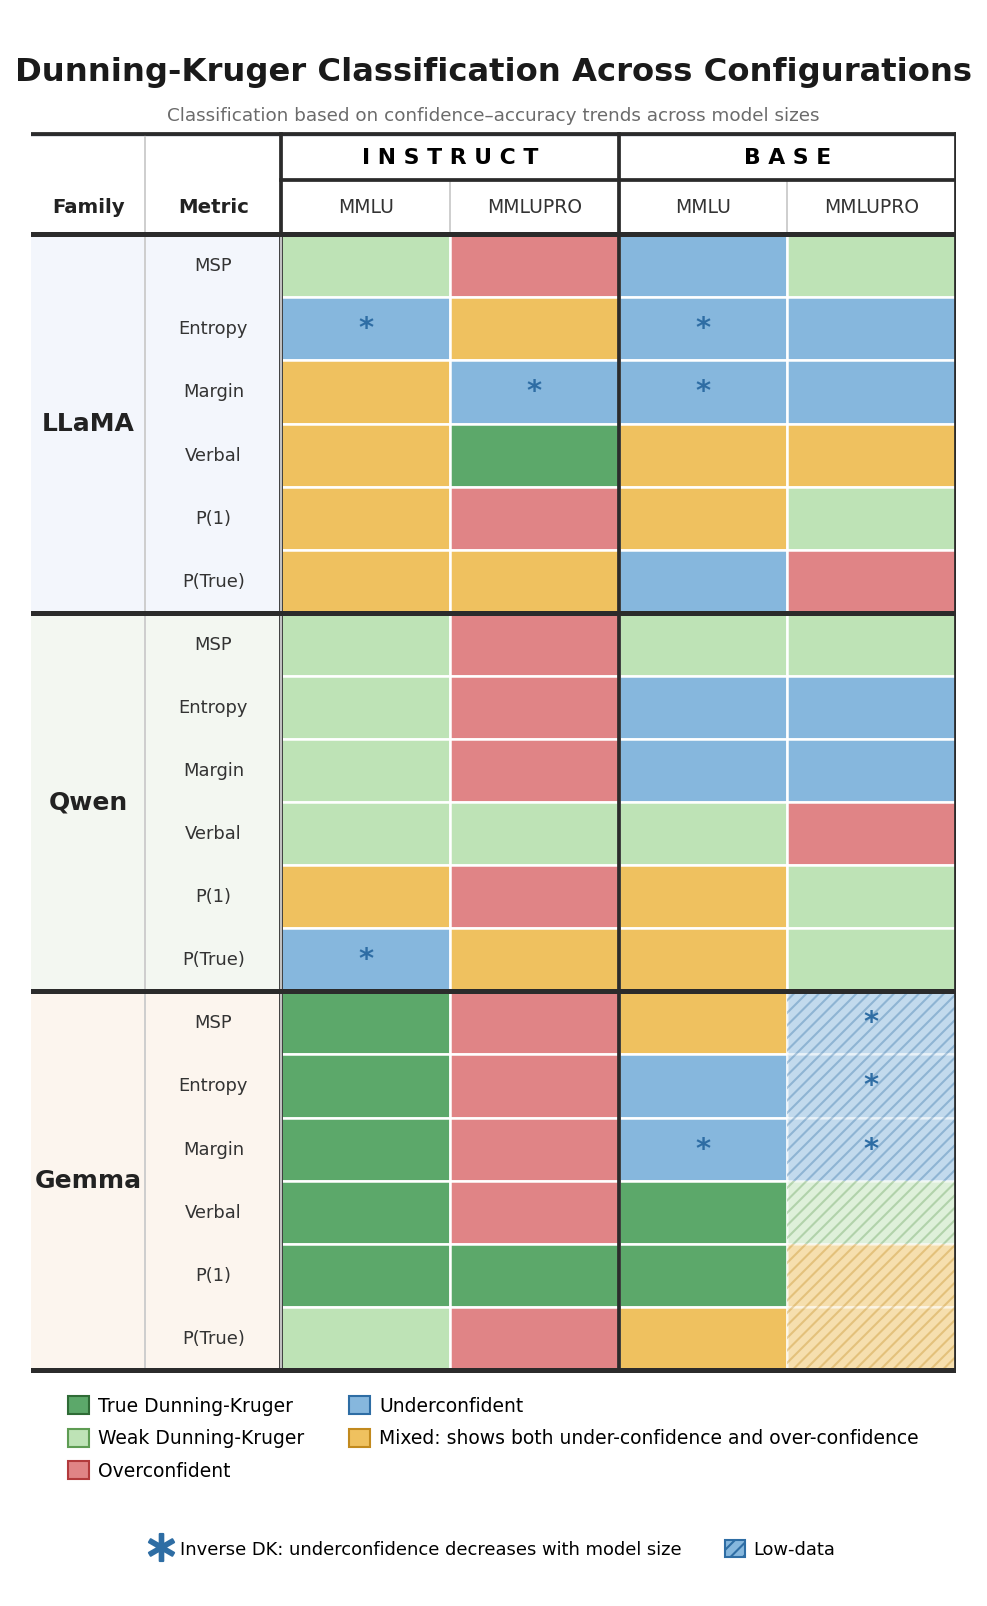

In [7]:
fig = render_table(CONFIG, DATA)
plt.show()

## 5. Quick reference

**Change one cell** — edit its tuple in `DATA`:
```python
DATA["LLaMA"]["MSP"][0] = ("OC", "")                                   # plain
DATA["LLaMA"]["Entropy"][0] = ("UC", "", {"inverse_dk": True})         # adds *
DATA["Gemma"]["MSP"][3] = ("UC", "", {"inverse_dk": True, "low_data": True})
```

**Markers:** `{"inverse_dk": True}` on a UC cell adds the `*`; `{"low_data": True}`
fades + hatches the cell.

**Recolour a category** — edit `LABEL_STYLES`.
**Add a family** — append to `CONFIG["families"]` and add a block to `DATA`.
**Resize** — tweak `row_h`, `data_col_w`, or `scale` inside `render_table`.

In [ ]:
######toe delte

In [8]:
def parse_cell(entry):
    """Return (label, inverse_dk, low_data) from a cell tuple."""
    label = entry[0]
    inverse_dk = low_data = False
    if len(entry) >= 3 and isinstance(entry[2], dict):
        inverse_dk = bool(entry[2].get("inverse_dk", False))
        low_data = bool(entry[2].get("low_data", False))
    return label, inverse_dk, low_data


def render_table(config, data,
                 savepath_png="dk_classification_table_compact.png",
                 savepath_pdf="dk_classification_table_compact.pdf"):
    families = config["families"]
    metrics  = config["metrics"]
    groups   = config["column_groups"]
    all_columns = [c for _, cols in groups for c in cols]
    n_cols = len(all_columns)

    # ---- Geometry: compact, uniform short rows ----
    family_col_w, metric_col_w, data_col_w = 1.05, 1.25, 1.55
    row_h = 0.58
    title_h, group_h, colhdr_h = 0.95, 0.42, 0.50
    legend_h, top_pad, bottom_pad = 1.30, 0.15, 0.10

    grid_h  = len(families) * len(metrics) * row_h
    total_w = family_col_w + metric_col_w + n_cols * data_col_w
    total_h = top_pad + title_h + group_h + colhdr_h + grid_h + legend_h + bottom_pad

    scale = 0.74
    fig, ax = plt.subplots(figsize=(total_w * scale, total_h * scale), dpi=150)
    fig.patch.set_facecolor("white")
    ax.set_xlim(0, total_w); ax.set_ylim(0, total_h)
    ax.set_aspect("equal"); ax.axis("off")

    grid_left = family_col_w + metric_col_w
    sep_x = grid_left + len(groups[0][1]) * data_col_w
    DARK, HAIR = "#2B2B2B", "#FFFFFF"

    # ---- Title (clean — no heavy black bar) ----
    title_y = total_h - top_pad - title_h
    ax.text(total_w / 2, title_y + title_h * 0.60, config["title"],
            ha="center", va="center", fontsize=15.5, fontweight="bold", color="#1A1A1A")
    ax.text(total_w / 2, title_y + title_h * 0.18, config["subtitle"],
            ha="center", va="center", fontsize=8.8, color="#6B6B6B")
    ax.plot([0, total_w], [title_y, title_y], color="#334155", linewidth=1.6, zorder=3)

    # ---- Group header (INSTRUCT / BASE) ----
    group_y = title_y - group_h
    cur = grid_left
    for gname, cols in groups:
        span = len(cols) * data_col_w
        ax.add_patch(Rectangle((cur, group_y), span, group_h,
                               facecolor=GROUP_COLORS[gname], edgecolor="none", zorder=2))
        ax.text(cur + span / 2, group_y + group_h / 2, " ".join(gname),
                ha="center", va="center", fontsize=10.5, fontweight="bold",
                color="black", zorder=3)
        cur += span

    # ---- Column sub-labels + Family / Metric headers ----
    colhdr_y = group_y - colhdr_h
    ax.text(family_col_w / 2, colhdr_y + colhdr_h / 2, "Family",
            ha="center", va="center", fontsize=9.5, fontweight="bold", color="#222")
    ax.text(family_col_w + metric_col_w / 2, colhdr_y + colhdr_h / 2, "Metric",
            ha="center", va="center", fontsize=9.5, fontweight="bold", color="#222")
    col_x, cur = [], grid_left
    for label in all_columns:
        col_x.append(cur)
        ax.text(cur + data_col_w / 2, colhdr_y + colhdr_h / 2, label,
                ha="center", va="center", fontsize=9, color="#333")
        cur += data_col_w

    # ---- Body cells (flush, no spacing) ----
    grid_top = colhdr_y
    grid_bot = grid_top - grid_h
    row_top = grid_top
    for fam in families:
        block_h = len(metrics) * row_h
        block_top, block_bot = row_top, row_top - block_h
        ax.add_patch(Rectangle((0, block_bot), grid_left, block_h,
                               facecolor=FAMILY_TINTS[fam], edgecolor="none",
                               alpha=0.7, zorder=0))
        ax.text(family_col_w / 2, (block_top + block_bot) / 2, fam,
                ha="center", va="center", fontsize=12, fontweight="bold",
                color="#222", zorder=3)
        ry = block_top
        for metric in metrics:
            ry_bot = ry - row_h
            ax.text(family_col_w + metric_col_w / 2, (ry + ry_bot) / 2, metric,
                    ha="center", va="center", fontsize=8.6, color="#333", zorder=3)
            for ci, entry in enumerate(data[fam][metric]):
                label, inverse_dk, low_data = parse_cell(entry)
                style = LABEL_STYLES[label]
                x = col_x[ci]
                alpha = 0.5 if low_data else 1.0
                ax.add_patch(Rectangle((x, ry_bot), data_col_w, row_h,
                                       facecolor=style["fill"], edgecolor=HAIR,
                                       linewidth=0.8, alpha=alpha, zorder=1))
                if low_data:
                    ax.add_patch(Rectangle((x, ry_bot), data_col_w, row_h,
                                           facecolor="none", edgecolor=style["edge"],
                                           hatch="////", linewidth=0, alpha=0.35, zorder=2))
                if inverse_dk:
                    ax.text(x + data_col_w / 2, (ry + ry_bot) / 2, "*",
                            ha="center", va="center", fontsize=14,
                            fontweight="bold", color=style["edge"], zorder=3)
            ry = ry_bot
        row_top = block_bot

    # ---- Structural lines ----
    ax.add_patch(Rectangle((grid_left, grid_bot), n_cols * data_col_w, grid_h,
                           facecolor="none", edgecolor=DARK, linewidth=1.8, zorder=4))
    yy = grid_top
    for _ in families[:-1]:                     # thick dark family dividers
        yy -= len(metrics) * row_h
        ax.plot([0, total_w], [yy, yy], color=DARK, linewidth=2.4, zorder=5)
    ax.plot([0, total_w], [grid_top, grid_top], color=DARK, linewidth=2.4, zorder=5)
    ax.plot([0, total_w], [grid_bot, grid_bot], color=DARK, linewidth=2.4, zorder=5)
    ax.plot([sep_x, sep_x], [grid_bot, group_y + group_h], color=DARK,
            linewidth=1.8, zorder=5)            # INSTRUCT | BASE divider
    for xx in (family_col_w, grid_left):
        ax.plot([xx, xx], [grid_bot, colhdr_y + colhdr_h], color="#CCCCCC",
                linewidth=0.9, zorder=4)

    # ---- Key (every meaning stated once) ----
    # 2 columns so the longer "Mixed" label drops to its own row rather than
    # overflowing the right edge.
    cat_handles = [Patch(facecolor=LABEL_STYLES[k]["fill"],
                         edgecolor=LABEL_STYLES[k]["edge"], linewidth=1.0,
                         label=LABEL_STYLES[k]["name"])
                   for k in ["DK", "WDK", "OC", "UC", "MX"]]
    marker_handles = [
        Line2D([0], [0], marker=r"$\ast$", linestyle="none", markersize=13,
               markerfacecolor=LABEL_STYLES["UC"]["edge"],
               markeredgecolor=LABEL_STYLES["UC"]["edge"],
               label="Inverse DK: underconfidence decreases with model size"),
        Patch(facecolor=LABEL_STYLES["UC"]["fill"], edgecolor=LABEL_STYLES["UC"]["edge"],
              hatch="////", linewidth=1.0, label="Low-data"),
    ]

    # Category key, anchored just under the grid (in data coords).
    leg1 = ax.legend(handles=cat_handles, loc="upper center",
                     bbox_to_anchor=(total_w / 2, grid_bot - 0.12),
                     bbox_transform=ax.transData, ncol=2, frameon=False,
                     handlelength=1.1, handleheight=1.1, columnspacing=2.4,
                     handletextpad=0.5, labelspacing=0.7,
                     fontsize=9, borderpad=0.2)
    ax.add_artist(leg1)

    # Measure where it ends, then place the markers right below it.
    fig.canvas.draw()
    rnd = fig.canvas.get_renderer()
    inv = ax.transData.inverted()
    leg1_bottom = inv.transform((0, leg1.get_window_extent(rnd).y0))[1]

    leg2 = ax.legend(handles=marker_handles, loc="upper center",
                     bbox_to_anchor=(total_w / 2, leg1_bottom - 0.14),
                     bbox_transform=ax.transData, ncol=2, frameon=False,
                     handlelength=1.1, handleheight=1.1, columnspacing=2.4,
                     handletextpad=0.5, fontsize=8.6, borderpad=0.2)

    # Crop the figure so it finishes just beneath the marker row.
    fig.canvas.draw()
    content_bottom = inv.transform((0, leg2.get_window_extent(rnd).y0))[1]
    new_bottom = content_bottom - 0.18
    ax.set_ylim(new_bottom, total_h)
    fig.set_size_inches(total_w * scale, (total_h - new_bottom) * scale, forward=True)

    fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)
    if savepath_png:
        fig.savefig(savepath_png, dpi=200, bbox_inches="tight", facecolor="white")
    if savepath_pdf:
        fig.savefig(savepath_pdf, bbox_inches="tight", facecolor="white")
    return fig